In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import warnings
import datetime
warnings.simplefilter("ignore", FutureWarning)

from demand_ninja.core import demand

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import LightGBMModel, TFTModel, XGBModel

curr_dir = pathlib.Path(".")
data_dir = curr_dir / "RTS-GMLC-master" / "RTS_Data"
load_data_dir = curr_dir / "load-data"

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


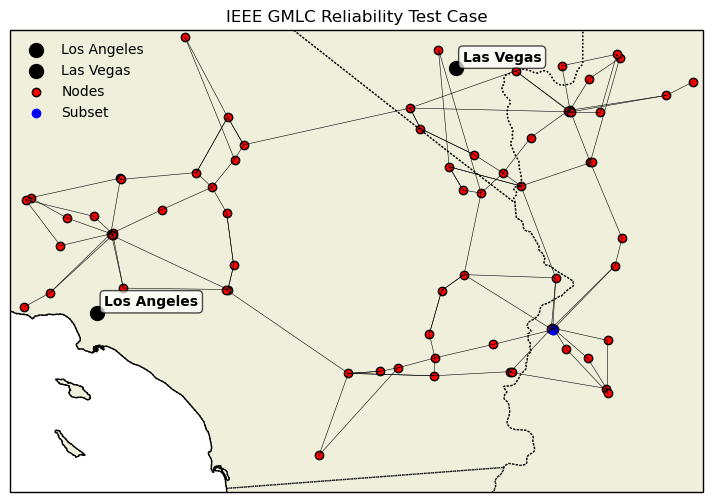

In [18]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

buses = [111]

# Read in bus/line geodata for IEEE RTS GMLC (Reliability Test System)
df_bus = pd.read_csv(curr_dir / "RTS-GMLC-master" / "RTS_Data" / "SourceData" / "bus.csv", index_col=[0])
df_geodata = df_bus[["lat", "lng"]]
df_line = pd.read_csv(curr_dir / "RTS-GMLC-master" / "RTS_Data" / "SourceData" / "branch.csv")
df_line = df_line.set_index(["From Bus", "To Bus"])

# Overlay system on map of US Southwest
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Add features (coastlines, states)
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot cities
cities = {
    "Los Angeles": (34.0522, -118.2437),
    "Las Vegas": (36.1699, -115.1398)
}
for city, (lat, lon) in cities.items():
    ax.scatter(lon, lat, color='black', edgecolor='black', s=100, label=city)
    ax.annotate(city, xy=(lon, lat), xytext=(5, 5), textcoords="offset points",
                fontsize=10, fontweight="bold", color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="black", boxstyle="round,pad=0.3"))

# Plot lines
for from_bus, to_bus in df_line.index:
    ax.plot(df_geodata.loc[[from_bus, to_bus], "lng"], df_geodata.loc[[from_bus, to_bus], "lat"], color="black", linewidth=0.4)

# Plot nodes
ax.scatter(df_geodata["lng"], df_geodata["lat"], color='red', edgecolor="black", transform=ccrs.PlateCarree(), label='Nodes')
ax.scatter(df_geodata.loc[buses, "lng"], df_geodata.loc[buses, "lat"], color="blue", transform=ccrs.PlateCarree(), label='Subset')
ax.set_extent([-119, -113, 32.5, 36.5], crs=ccrs.PlateCarree())

plt.legend()
plt.title("IEEE GMLC Reliability Test Case")
plt.show()

### Statistical Modeling Approach: For 2019-2024 data

#### Background:

We only have access to regional demand. We wish to learn a nodal demand model, however.

#### Approach:
1. Create multiple training data sets for a subset of buses; the *targets* will be the same, but the *inputs* will be different in each data set. I.e., we will train a single model $f_\theta(x)$ which minimizes: $\frac{1}{MN} \sum_{m=1}^{M} \sum_{n=1}^{N} |f_\theta(x_{mn}) - y_n|^2$ where $m$ indexes nodes and $n$ indexes data points.
2. Predict load timeseries for all nodes using the trained model: $\hat{y}_{mn} = f_\theta(x_{mn})$.

<Axes: xlabel='datetime'>

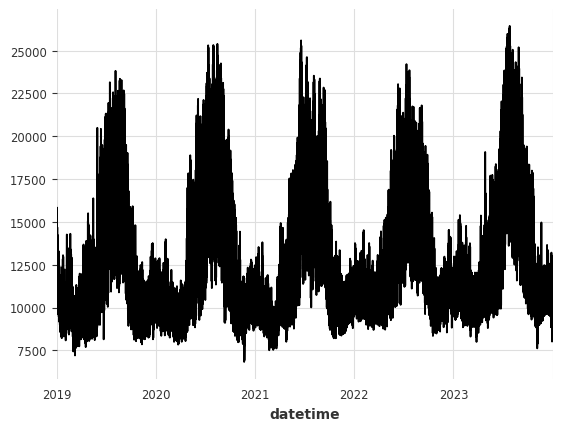

In [64]:
# Read in historical regional demand

years = [2019, 2020, 2021, 2022, 2023]

df = pd.read_csv(load_data_dir / "historical" / "EIA_hourly_load_2019_2025.csv")
df_load = df.loc[df["type-name"] == "Demand"]
df_load = df_load.pivot(index=["datetime"], columns=["respondent"], values=["value"])
df_load.columns = df_load.columns.droplevel(0)
df_load.index = pd.to_datetime(df_load.index)

# Get subset of data
df_sw = df_load["SW"]
df_sw = df_sw.loc[df_sw.index.year.isin(years)]
df_sw.plot()

In [65]:
# Read in list of buses
df_bus = pd.read_csv(curr_dir / "RTS-GMLC-master" / "RTS_Data" / "SourceData" / "bus.csv", index_col=[0])
buses = [111, 211, 311] # Subset of buses
df_features_buses = {}
for bus in buses:
    df_weather_concat = pd.DataFrame()
    for year in years:
        fname = load_data_dir / "inputs" / f"bus{bus}" / f"NSRDB_weather-inputs_bus{bus}_{year}.csv"
        if not fname.exists():
            skip_bus = True
            continue
        df_weather = pd.read_csv(fname, index_col=["datetime"])
        df_weather.index = pd.to_datetime(df_weather.index)
    
        # Get subset of columns needed for load calculation
        df_weather = df_weather[["Temperature", "Relative Humidity", "GHI", "Wind Speed"]]
        df_weather.columns = ["temperature", "humidity", "radiation_global_horizontal", "wind_speed_2m"]
        df_weather_concat = pd.concat([df_weather_concat, df_weather])
    df_weather = df_weather_concat.copy()
    #df_weather.columns = pd.MultiIndex.from_product([[bus], df_weather.columns])

    # Create features
    df_features = df_weather.copy()

    # Calendar features
    df_features["hour_angle_sin"] = np.sin(2 * np.pi * df_features.index.hour / 24)
    df_features["hour_angle_cos"] = np.cos(2 * np.pi * df_features.index.hour / 24)
    df_features["year_angle_sin"] = np.sin(2 * np.pi * df_features.index.dayofyear / 365)
    df_features["year_angle_cos"] = np.cos(2 * np.pi * df_features.index.dayofyear / 365)
    
    # Other weather features
    df_features["temperature^2"] = df_features["temperature"]**2
    df_features["temperature^3"] = df_features["temperature"]**3
    df_features["temperature-humidity"] = df_features["temperature"] * df_features["humidity"]
    df_features["temperature-radiation"] = df_features["temperature"] * df_features["radiation_global_horizontal"]

    # Save features for bus
    df_features_buses[bus] = df_features

In [75]:
# Build Darts time series

# Demand and featueres
regional_demand = TimeSeries.from_series(df_sw)
def features_cov_func(df_features):
    return TimeSeries.from_dataframe(
        df_features,
        value_cols=[
            "hour_angle_sin",
            "hour_angle_cos",
            "year_angle_sin",
            "year_angle_cos",
            "temperature",
            "temperature^2",
            "temperature^3",
            "humidity",
            "temperature-humidity",
            "wind_speed_2m",
            "radiation_global_horizontal",
            "temperature-radiation",
        ],
    )

# Create lists of time series
demand_list = [regional_demand.copy() for _ in buses]
features_cov_list = [features_cov_func(df_features_buses[bus]) for bus in buses]

# Create weights
df_weight = (1 + 4 * (df_sw > df_sw.quantile(0.95)))
weights = TimeSeries.from_series(df_weight)

# Normalize data
scalers_d = []
scalers_f = []
demand_scaled_list = []
features_scaled_list = []

# Scale data
for demand, features in zip(demand_list, features_cov_list):
    sd = Scaler()
    sf = Scaler()
    demand_scaled_list.append(sd.fit_transform(demand))
    features_scaled_list.append(sf.fit_transform(features))
    scalers_d.append(sd)
    scalers_f.append(sf)

# Train/validation split
split_after = pd.Timestamp("2022-12-31 23:00:00")

# Define lists
train_list, val_list = [], []
features_train_list, features_val_list = [], []
for d, f in zip(demand_scaled_list, features_scaled_list):
    # Split data
    train_d, val_d = d.split_after(split_after)
    train_f, val_f = f.split_after(split_after)
    # Save to lists
    train_list.append(train_d)
    val_list.append(val_d)
    features_train_list.append(train_f)
    features_val_list.append(val_f)
# Split weights
weights_train, _ = weights.split_after(split_after)
weights_train_list = [weights_train for _ in buses]

# XGBoost Model (ChatGPT - modify this part)
quantiles=[0.05, 0.25, 0.5, 0.75, 0.95]
model = XGBModel(
    lags=None,
    lags_future_covariates=(48,12),
    output_chunk_length=1,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    likelihood="quantile",
    quantiles=quantiles,
)

# Train
model.fit(
    series=train_list,
    future_covariates=features_train_list,
    sample_weight=weights_train_list,
)

XGBModel(lags=None, lags_past_covariates=None, lags_future_covariates=(48, 12), output_chunk_length=1, output_chunk_shift=0, add_encoders=None, likelihood=quantile, quantiles=[0.05, 0.25, 0.5, 0.75, 0.95], random_state=42, multi_models=True, use_static_covariates=True, n_estimators=500, learning_rate=0.05, max_depth=6)

In [113]:
# Define Markov process
def markov_uniform(T):
    rho = 0.9  # correlation parameter
    u = np.zeros(T)
    u[0] = np.random.rand()
    for t in range(1, T):
        v = np.random.rand()
        u[t] = rho * u[t-1] + (1 - rho) * v
    return u

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

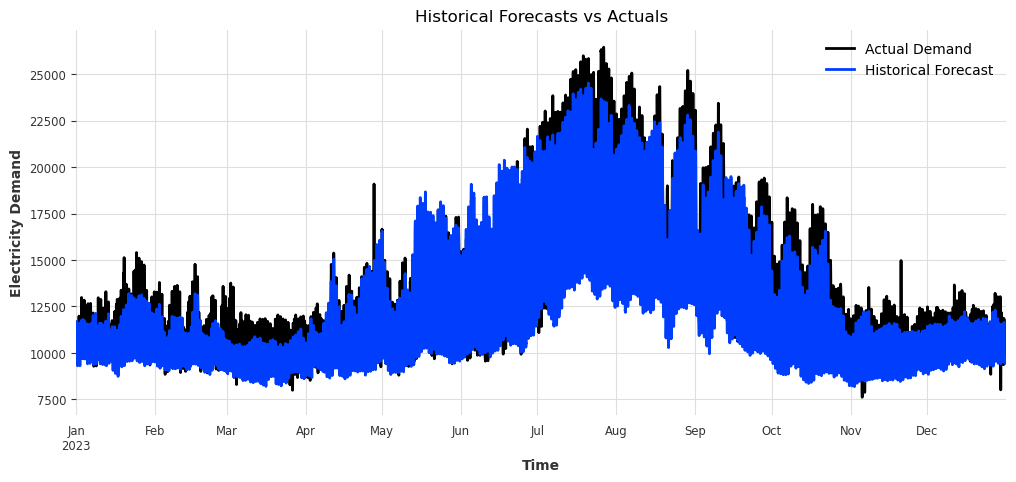

In [114]:
# Generate historical forecasts over the validation period (LightGBM Model)
bus_idx = 0
prob_forecast = model.historical_forecasts(
    series=demand_scaled_list[bus_idx],
    future_covariates=features_scaled_list[bus_idx],
    forecast_horizon=1,
    start=pd.Timestamp("2023-01-01 00:00:00"),  # start of validation
    stride=1,                # forecast every 24 hours
    retrain=False,             # re-train at each step
    verbose=True,
    last_points_only=True,
    predict_likelihood_parameters=True,
)
# Re-scale
prob_forecast = scalers_d[bus_idx].inverse_transform(prob_forecast)

# Convert to dataframe
prob_forecast = prob_forecast.to_dataframe()

# Sample quantiles of the probabilistic forecast randomly
probs = np.cumsum([0.05, 0.2, 0.5, 0.2, 0.05])
quantile_cols = prob_forecast.columns
np.random.seed(0)
u_arr = markov_uniform(len(prob_forecast))

# Map uniform random number to quantile column
def select_quantile(u):
    for q_col, prob in zip(quantile_cols, probs):
        if u <= prob:
            return q_col
# Vectorized mapping
selected_quantiles = np.vectorize(select_quantile)(u_arr)

# Sample the forecast

# Melt the DataFrame so each row is (timestamp, quantile, value)
prob_forecast_melted = prob_forecast.reset_index().melt(
    id_vars="index", var_name="quantile", value_name="value"
)

# Create a DataFrame mapping each timestamp to the randomly selected quantile
selection_df = pd.DataFrame({
    "index": prob_forecast.index,
    "quantile": selected_quantiles
})

# Merge to select the corresponding forecast values
forecast = selection_df.merge(
    prob_forecast_melted,
    on=["index", "quantile"],
    how="left"
).set_index("index")["value"]

# Convert back to series
forecast = TimeSeries.from_series(forecast)

# Slice actual demand for the same period
actuals = regional_demand.slice(split_after, regional_demand.end_time())

plt.figure(figsize=(12,5))
actuals.plot(label="Actual Demand")
forecast.plot(label="Historical Forecast")
plt.title("Historical Forecasts vs Actuals")
plt.xlabel("Time")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()

In [80]:
save = False
if save:
    # Save model
    model_path = load_data_dir / "models" / "XGBoost_prob_model_20251204"
    model.save(str(model_path))

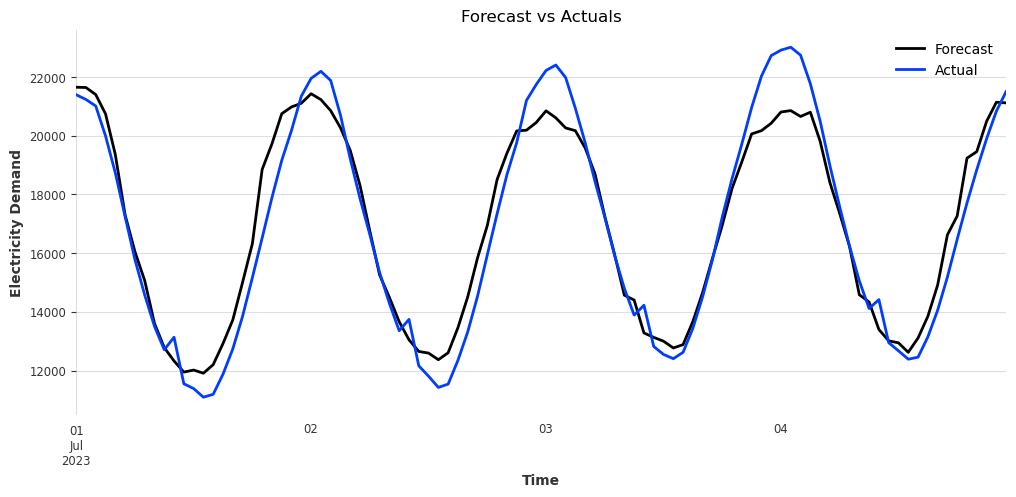

In [115]:
# Define sample period
start = pd.Timestamp("2023-07-01 00:00:00")
end   = pd.Timestamp("2023-07-04 23:00:00")

# Slice forecast and actual
forecast_week = forecast.slice(start, end)
actual_week   = actuals.slice(start, end)

plt.figure(figsize=(12,5))
forecast_week.plot(label="Forecast", lw=2)
actual_week.plot(label="Actual", lw=2)
plt.title("Forecast vs Actuals")
plt.xlabel("Time")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()

### Converting weather data to load data with DemandNinja

In [ ]:
### Create load profiles; normalize to 2006 load data

# Read in list of buses
df_bus = pd.read_csv(curr_dir / "RTS-GMLC-master" / "RTS_Data" / "SourceData" / "bus.csv", index_col=[0])

for bus in df_bus.index:
    print(bus)
    skip_bus = False
    years = np.arange(1998, 2024)
    df_in_concat = pd.DataFrame()
    for year in years:
        fname = load_data_dir / "inputs" / f"bus{bus}" / f"NSRDB_weather-inputs_bus{bus}_{year}.csv"
        if not fname.exists():
            skip_bus = True
            continue
        df_in = pd.read_csv(fname, index_col=["datetime"])
        df_in.index = pd.to_datetime(df_in.index)

        # Get subset of columns needed for load calculation in demand ninja
        df_in = df_in[["Temperature", "Relative Humidity", "GHI", "Wind Speed"]]
        df_in.columns = ["temperature", "humidity", "radiation_global_horizontal", "wind_speed_2m"]
        df_in_concat = pd.concat([df_in_concat, df_in])
    df_in = df_in_concat.copy()

    if skip_bus:
        print("Skipping bus", bus)
        continue
    
    # Calculate demand with demand ninja
    df_out = demand(
        df_in,
        base_power=10,
        heating_power=0.8,
        cooling_power=1.2,
        cooling_threshold=16.0,
        heating_threshold=24.0,
        humidity_discomfort=0.003,
        solar_gains=0.01,
        smoothing=0.5,
    )["total_demand"]

    # Normalize by peak load in 2006
    peak_2006 = df_out.loc[df_out.index.year == 2006].max()
    df_out /= peak_2006

    # Save data
    # Profiles directory
    bus_dir = load_data_dir / "profiles" / f"bus{bus}"
    bus_dir.mkdir(exist_ok=True, parents=True)
    for year in years:
        df_out_year = df_out.loc[df_out.index.year == year]
        df_out_year.to_csv(bus_dir / f"NSRDB_load-profile_bus{bus}_{year}.csv")

In [ ]:
### DIAGNOSTICS / tuning the load model

In [ ]:
# Read in list of buses
df_bus = pd.read_csv(curr_dir / "RTS-GMLC-master" / "RTS_Data" / "SourceData" / "bus.csv", index_col=[0])

In [ ]:
# Seasons
summer = [6, 7, 8, 9]
winter = [11, 12, 1, 2]
shoulder = [10, 3, 4, 5]

In [ ]:
# Read in NSRDB input data + convert to load data
diagnostics = True
for bus in df_bus.index:
    print(bus)
    skip_bus = False
    years = [2021, 2022, 2023]
    df_in_concat = pd.DataFrame()
    for year in years:
        fname = load_data_dir / "inputs" / f"bus{bus}" / f"NSRDB_weather-inputs_bus{bus}_{year}.csv"
        if not fname.exists():
            skip_bus = True
            continue
        df_in = pd.read_csv(fname, index_col=["datetime"])
        df_in.index = pd.to_datetime(df_in.index)

        # Get subset of columns needed for load calculation in demand ninja
        df_in = df_in[["Temperature", "Relative Humidity", "GHI", "Wind Speed"]]
        df_in.columns = ["temperature", "humidity", "radiation_global_horizontal", "wind_speed_2m"]
        df_in_concat = pd.concat([df_in_concat, df_in])
    df_in = df_in_concat.copy()

    if skip_bus:
        print("Skipping bus", bus)
        continue
    
    # Calculate demand with demand ninja
    df_out = demand(
        df_in,
        base_power=10,
        heating_power=0.8,
        cooling_power=1.3,
        cooling_threshold=18.0,
        heating_threshold=20.0,
        humidity_discomfort=0.003,
        solar_gains=0.01,
        smoothing=0.01,
        use_diurnal_profile=False
    )["total_demand"]
    
    if diagnostics:
        # Get subset of Southwest demand for years
        df_sw = df_sw.loc[df_sw.index.year.isin(years)]
    
        # Plot
        df_out_norm = df_out / df_out.mean()
        df_sw_norm = df_sw / df_sw.mean()
        df_out_norm.plot()
        df_sw_norm.loc[df_in.index].plot(alpha=0.5)
        plt.show()
    
        plt.scatter(df_in["temperature"], df_out_norm, s=3, alpha=0.1)
        plt.scatter(df_in["temperature"], df_sw_norm.loc[df_in.index], s=3, alpha=0.1)
        plt.show()
    
        # Plot load shapes
        for season in [summer, winter, shoulder]:
            print(season)
            df_sw_season = df_sw_norm.loc[df_sw_norm.index.month.isin(season)]
            df_out_season = df_out_norm.loc[df_out_norm.index.month.isin(season)]
            df_in_season = df_in.loc[df_in.index.month.isin(season)]
            plt.plot(df_sw_season[0:168])
            plt.plot(df_out_season[0:168])
            plt.title("Load")
            plt.show()

            plt.plot(df_in_season["temperature"][0:168])
            plt.title("Temp")
            plt.show()
            
            # df_sw_season_24hr = df_sw_season.groupby(df_sw_season.index.hour).mean()
            # df_out_season_24hr = df_out_season.groupby(df_out_season.index.hour).mean()
    
            # plot_sw = pd.concat([df_sw_season_24hr.iloc[8:], df_sw_season_24hr.iloc[0:8]])
            # plot_out = df_out_season_24hr
    
            # plt.plot(plot_out.values)
            # plt.plot(plot_sw.values)
            # plt.title("Load")
            # plt.show()
    
            # df_in_season = df_in.loc[df_in.index.month.isin(season)]
            # df_in_season_24hr = df_in_season["temperature"].groupby(df_in_season.index.hour).mean()
            # plt.plot(df_in_season_24hr)
            # plt.title("Temp")
            # plt.show()

In [ ]:
df_out

### Downloading + processing EIA load data

In [ ]:
# Read in API key
with open("eia-api-key.txt", "r") as f:
    API_KEY = f.readlines()[0].strip()

In [ ]:
BASE_URL = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

RESPONDENTS = ["AZPS", "PNM", "SRP"]

START_DATE = "2016-01-01T00"
END_DATE   = "2018-12-31T00"

MAX_ROWS = 5000  # API row limit per request
DELAY = 0.2      # seconds between requests to avoid rate limits

def fetch_page(offset=0):
    """Fetch a single page of results from the EIA API."""
    params = {
        "api_key": API_KEY,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": RESPONDENTS,
        "start": START_DATE,
        "end": END_DATE,
        "sort[0][column]": "period",
        "sort[0][direction]": "desc",
        "offset": offset,
        "length": MAX_ROWS
    }
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    data = response.json().get("response", {}).get("data", [])
    return data

def fetch_all_data():
    """Fetch all rows by paginating through the API."""
    all_data = []
    offset = 0
    
    while True:
        print(f"Fetching rows starting at offset {offset} ...")
        page = fetch_page(offset)
        if not page:
            break
        all_data.extend(page)
        if len(page) < MAX_ROWS:
            break
        offset += MAX_ROWS
        time.sleep(DELAY)
    
    print(f"Total rows fetched: {len(all_data)}")
    return all_data

def main():
    data = fetch_all_data()
    if not data:
        print("No data retrieved.")
        return
    
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['period'])
    df = df.sort_values(['respondent', 'datetime'])
    
    # Save to CSV
    df.to_csv("EIA_hourly_load_2016_2018.csv", index=False)
    print("Saved to EIA_hourly_load_2016_2018.csv")

if __name__ == "__main__":
    main()

In [ ]:
# Read-in and organize load data
df = pd.read_csv(load_data_dir / "historical" / "EIA_hourly_load_2019_2025.csv")
df_load = df.loc[df["type-name"] == "Demand"]
df_load = df_load.pivot(index=["datetime"], columns=["respondent"], values=["value"])
df_load.columns = df_load.columns.droplevel(0)
df_load.index = pd.to_datetime(df_load.index)

In [ ]:
# Clean load data

df_load_clean = df_load.copy()
low_cutoffs = {col: 100 for col in df_load_clean.columns}
low_cutoffs["LDWP"] = 1000
low_cutoffs["WALC"] = 400
for col in df_load.columns:
    
    # Identify large percentage changes in data (indicating erroneous data)
    bwd_pct_change = (df_load_clean[col] + 1).pct_change(periods=1, fill_method=None).abs()
    fwd_pct_change = (df_load_clean[col] + 1).pct_change(periods=-1, fill_method=None).abs()
    pct_change = pd.concat([fwd_pct_change, bwd_pct_change], axis=1).max(axis=1)
    big_deltas = (pct_change > 0.2)
    
    # Identify where time series is below cutoff
    zeros = (df_load_clean[col] < low_cutoffs[col])

    # Flag index at these times
    flag_inds = df_load_clean[col].index[big_deltas | zeros]
    
    # Remove data at these times
    df_load_clean.loc[flag_inds, col] = np.nan
    
    # Identify large rolling z-scores
    window = 168
    rolling_mean = df_load_clean[col].rolling(window=window, min_periods=1, center=True).mean()
    rolling_std = df_load_clean[col].rolling(window=window, min_periods=1, center=True).std()
    rolling_zscore = (df_load_clean[col] - rolling_mean) / rolling_std
    big_zscores = (rolling_zscore > 3)

    # Flag index at these times
    flag_inds = df_load_clean[col].index[big_deltas | zeros | big_zscores]

     # Remove data at these times
    df_load_clean.loc[flag_inds, col] = np.nan

    # Interpolate data
    df_load_clean[col] = df_load_clean[col].interpolate(method="time")
    
    # Plot cleaned data
    df_load_clean[col].plot()
    plt.title(col)
    plt.show()

In [ ]:
# Calibrating Demand Ninja parameters with cleaned load data
summer = [5,6,7,8,9,10]
winter = [11,12,1,2,3,4]
shoulder = [4,11]

In [ ]:
# Get summer/winter load
df_sw = df_load_clean["SW"]
df_sw_summer = df_sw.loc[df_sw.index.month.isin(summer)]
df_sw_winter = df_sw.loc[df_sw.index.month.isin(winter)]

In [ ]:
# Get summer/winter peaks
summer_peaks = df_sw_summer.groupby(df_sw_summer.index.year).max()
winter_peaks = df_sw_winter.groupby(df_sw_winter.index.year).max()

In [ ]:
# Ratio of summer to winter peaks
summer_peaks / winter_peaks

In [ ]:
# Get shoulder season baseline demand
shoulder = [3,11]
df_sw_shoulder = df_sw.loc[df_sw.index.month.isin(shoulder)]
shoulder_mins = df_sw_shoulder.groupby(df_sw_shoulder.index.year).min()
summer_peaks / shoulder_mins